### Credit Card Fraud Detection

Dataset from Kaggle : https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

In [137]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
path = 'data/creditcard.csv'
df = pd.read_csv(path) #importing csv file
colors = ["#ff0000", "#0000ff"] #color palette for graphs


### EDA

In [79]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [80]:
df.shape

(284807, 31)

The dataset consist of 31 columns and 284807 records.

In [81]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [82]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

In [116]:
no_fraud = df['Class'].value_counts()[0]
fraud = df["Class"].value_counts()[1]
print("No Fraud:", no_fraud)
print("Fraud:", fraud)

percentage_of_no_fraud = round(no_fraud/len(df) * 100, 2)
percentage_of_fraud = round(fraud/len(df) * 100, 2)
print(percentage_of_no_fraud, "% of No Fraund in dataset.")
print(percentage_of_fraud, "% of Fraud in dataset.")

No Fraud: 284315
Fraud: 492
99.83 % of No Fraund in dataset.
0.17 % of Fraud in dataset.


The dataset is imbalace. The model will overfit and assume that most transaction are NOT FRAUD.

Text(0.5, 1.0, 'Class Distribution \n (0: No Fraud || 1: Fraud)')

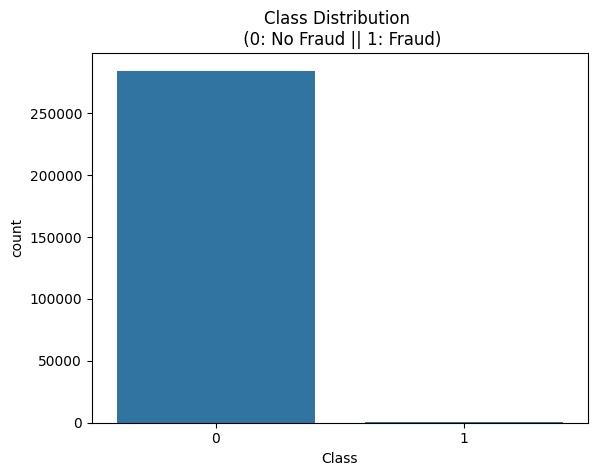

In [84]:
sns.countplot(x='Class', data=df)
plt.title("Class Distribution \n (0: No Fraud || 1: Fraud)")


We can see how skew the data is.

### Feature Engineering

Robust Scaler to scale remaning columns "Amount" & "Time"

In [91]:
#Scaling Remaining Columns : Time and Amount
from sklearn.preprocessing import RobustScaler

rob_scalar = RobustScaler() # Robust Scalar is less prone to outliers


scaled_df = df.copy(deep=True)
scaled_df['scaled_amount'] = rob_scalar.fit_transform(scaled_df['Amount'].values.reshape(-1,1))
scaled_df['scaled_time'] = rob_scalar.fit_transform(scaled_df['Time'].values.reshape(-1,1))



In [ ]:
scaled_df.drop(['Amount', 'Time'], axis=1, inplace=True) 

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,1.783274,-0.994983
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.269825,-0.994983
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,4.983721,-0.994972
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,1.418291,-0.994972
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,0.670579,-0.994960
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,...,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0,-0.296653,1.034951
284803,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,...,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,0,0.038986,1.034963
284804,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,...,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,0,0.641096,1.034975
284805,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,...,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,0,-0.167680,1.034975


In [95]:
scaled_df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,1.783274,-0.994983
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.269825,-0.994983
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,4.983721,-0.994972
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,1.418291,-0.994972
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,0.670579,-0.994960


#### Undersampling : Creating a dataframe with 50/50 ratio of fraud and non-fraud transaction.

Undersampling a dataset to have 50/50 Fraud/No Fraud Data

In [96]:
#Shuffing the data
scaled_df = scaled_df.sample(frac=1)

# amount of fraud classes 492 rows
fraud_df = scaled_df[df['Class'] == 1]
non_fraud_df = scaled_df[df['Class'] == 0][:492] #492 records only

normal_distributed_pdf = pd.concat([fraud_df, non_fraud_df])

#shuffle dataframe rows again
new_df = normal_distributed_pdf.sample(frac=1, random_state=42)
new_df.head()

C:\Users\User\AppData\Local\Temp\ipykernel_49220\725605322.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  fraud_df = scaled_df[df['Class'] == 1]
C:\Users\User\AppData\Local\Temp\ipykernel_49220\725605322.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  non_fraud_df = scaled_df[df['Class'] == 0][:492] #492 records only


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
41764,-6.611025,-6.131411,0.888709,0.238191,0.921489,-0.839990,-1.343990,0.251157,0.564323,0.692753,...,1.775037,3.359470,0.175007,0.502673,-0.160472,0.737761,-0.993190,0,1.355411,-0.515455
11841,-15.271362,8.326581,-22.338591,11.885313,-8.721334,-2.324307,-16.196419,0.512882,-6.333685,-13.175198,...,1.068019,1.085617,-1.039797,-0.182006,0.649921,2.149247,-1.406811,1,-0.293440,-0.756118
51316,-1.465283,-1.519046,1.399141,-2.705507,-0.132987,-1.654648,-0.187991,-0.215305,-2.097123,0.661835,...,0.070410,0.929611,0.324661,0.087774,-0.542661,0.130994,0.015727,0,-0.027947,-0.467604
41395,-4.446847,-0.014793,-5.126307,6.945130,5.269255,-4.297177,-2.591242,0.342671,-3.880663,-3.976525,...,-0.049586,-0.226017,-0.401236,0.856124,0.661272,0.492560,0.971834,1,-0.293440,-0.517276
247673,-5.192496,3.164721,-5.047679,2.246597,-4.011781,-0.638908,-2.873463,1.576318,-2.861986,-2.120458,...,-1.006617,0.774562,0.063397,-0.390658,1.884741,-1.742558,-0.082216,1,3.156012,0.810172


In [100]:
new_df.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
count,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,...,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000
mean,-2.305248,1.768245,-3.507844,2.311401,-1.608244,-0.698417,-2.763281,0.287885,-1.300617,-2.823765,...,0.018189,-0.021878,-0.060814,0.024720,0.022668,0.073158,0.033362,0.500000,1.234678,0.031505
std,5.520782,3.692038,6.221944,3.177638,4.239235,1.777539,5.885173,4.848964,2.305965,4.537797,...,1.170603,1.151965,0.570066,0.666876,0.480288,1.001383,0.427154,0.500254,3.752618,0.564851
min,-30.552380,-11.025614,-31.103685,-5.043049,-22.105532,-6.406267,-43.557242,-41.044261,-13.434066,-24.588262,...,-8.887017,-19.254328,-2.761047,-4.781606,-1.404504,-7.263482,-1.869290,0.000000,-0.307413,-0.993832
25%,-2.801438,-0.208240,-5.113334,-0.007299,-1.779765,-1.618422,-3.066415,-0.220423,-2.299787,-4.572043,...,-0.539103,-0.239400,-0.405936,-0.303129,-0.295349,-0.067643,-0.059831,0.000000,-0.290924,-0.451022
50%,-0.768368,0.939008,-1.334371,1.383843,-0.449094,-0.639991,-0.657278,0.147397,-0.712860,-0.869448,...,0.036374,-0.036075,-0.010616,0.078557,-0.030163,0.041396,0.028697,0.500000,-0.028506,-0.055792
75%,1.118574,2.765175,0.279310,4.235631,0.446624,0.074122,0.248668,0.860635,0.181022,0.052199,...,0.592842,0.189587,0.360319,0.408163,0.324074,0.429253,0.217477,1.000000,1.089779,0.588500
max,2.312160,22.057729,3.870585,12.114672,11.095089,11.038675,17.416779,20.007208,6.060883,10.824223,...,8.361985,5.466230,1.205448,2.208209,2.745261,3.052358,2.600268,1.000000,51.257458,1.032472


C:\Users\User\AppData\Local\Temp\ipykernel_49220\3399929641.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=new_df, palette=['#a1c9f4', '#8de5a1'])


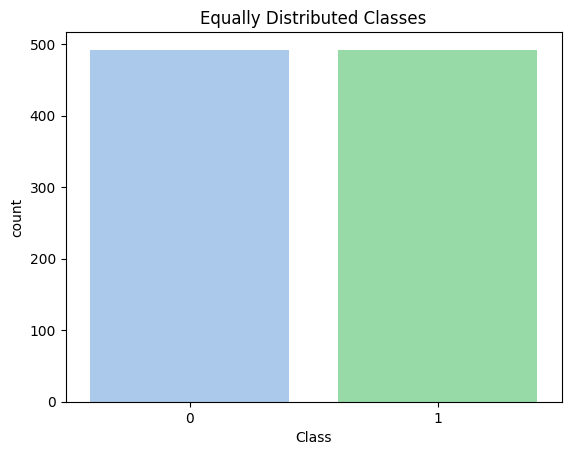

In [110]:
sns.countplot(x='Class', data=new_df, palette=['#a1c9f4', '#8de5a1'])
plt.title("Equally Distributed Classes")
plt.show()

New dataframe with 50% Fraud and 50% Non Fraud

### Second EDA

Correlation Metric to better understand our data. We want to know if there are features that influence heavily in whether a specific is a fraud.

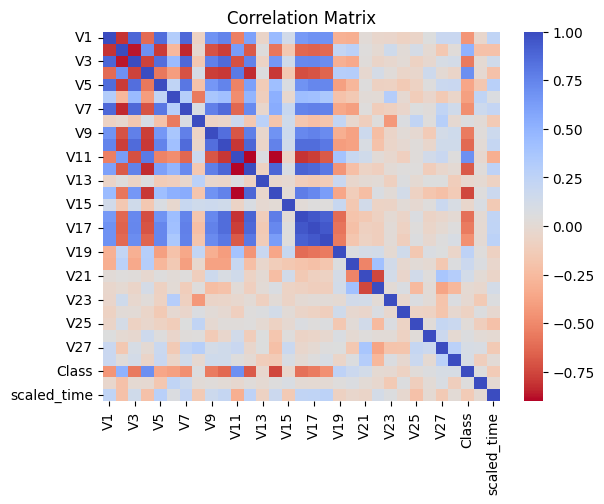

In [114]:
sns.heatmap(new_df.corr(), cmap='coolwarm_r')
plt.title("Correlation Matrix")
plt.show()

<b>Explanation</b>: 

Negative Correlations: V17, V14, V12 and V10 are negatively correlated. Meaning lower these values are, the more likely the end result will be fraud transaction.

Positive Correlations: V2, V4, V11 and V19 are positively correlated. Higher these values, more likely the ned result will be fraud transaction.

### Removing Outliers

#### Negative Correlations

Removing extreme outliers for better model accuracy

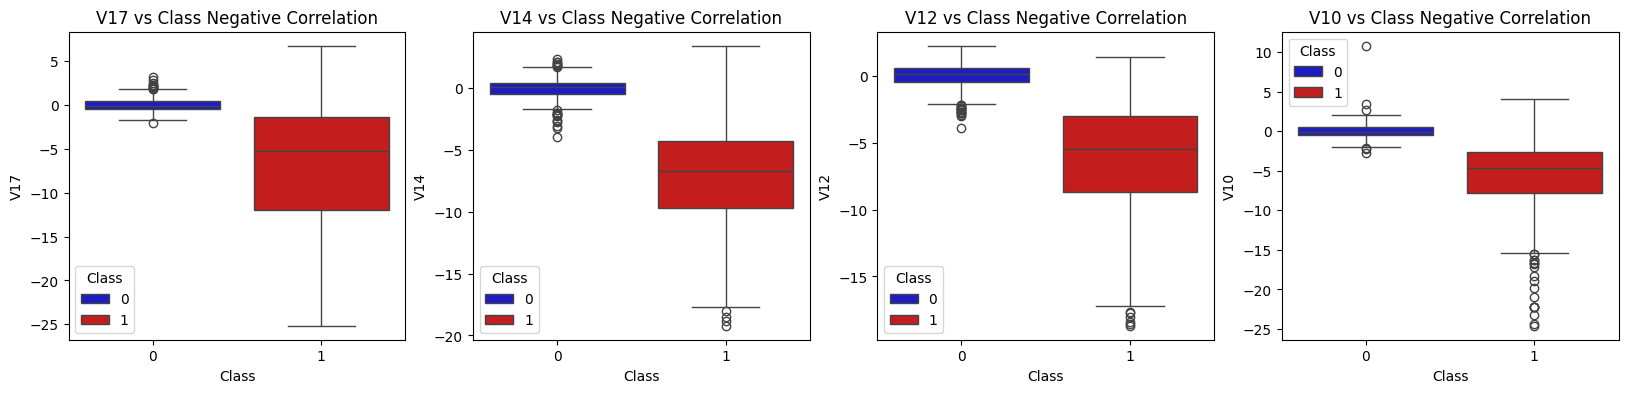

In [132]:
f, axes = plt.subplots(ncols=4, figsize =(20,4))
sns.boxplot(x='Class', y="V17", data=new_df, ax=axes[0], palette=colors, hue="Class")
axes[0].set_title("V17 vs Class Negative Correlation")

sns.boxplot(x='Class', y="V14", data=new_df, ax=axes[1], palette=colors, hue="Class")
axes[1].set_title("V14 vs Class Negative Correlation")

sns.boxplot(x='Class', y="V12", data=new_df, ax=axes[2], palette=colors,  hue="Class")
axes[2].set_title("V12 vs Class Negative Correlation")

sns.boxplot(x='Class', y="V10", data=new_df, ax=axes[3], palette=colors,  hue="Class")
axes[3].set_title("V10 vs Class Negative Correlation")
plt.show()

#### Positive Correlation

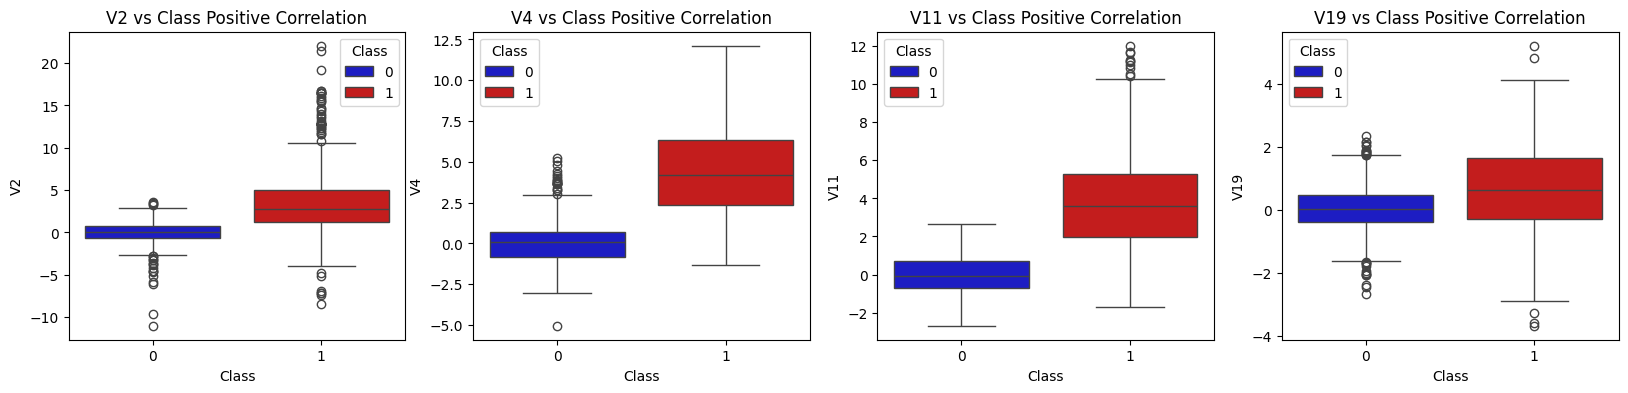

In [134]:
f, axes = plt.subplots(ncols=4, figsize =(20,4))
sns.boxplot(x='Class', y="V2", data=new_df, ax=axes[0], palette=colors, hue="Class")
axes[0].set_title("V2 vs Class Positive Correlation")

sns.boxplot(x='Class', y="V4", data=new_df, ax=axes[1], palette=colors, hue="Class")
axes[1].set_title("V4 vs Class Positive Correlation")

sns.boxplot(x='Class', y="V11", data=new_df, ax=axes[2], palette=colors,  hue="Class")
axes[2].set_title("V11 vs Class Positive Correlation")

sns.boxplot(x='Class', y="V19", data=new_df, ax=axes[3], palette=colors,  hue="Class")
axes[3].set_title("V19 vs Class Positive Correlation")
plt.show()

#### Removing V2 and V10 Feature outlier

Removing too much outliers can lose information make a model underfit.

In [138]:
#IQR
#For V2
v2_fraud = new_df['V2'].loc[new_df['Class']==1].values
q25, q75 = np.percentile(v2_fraud, 25), np.percentile(v2_fraud, 75)
v2_iqr = q75 - q25

v2_cut_off = v2_iqr * 1.5
v2_lower, v2_upper = q25 - v2_cut_off, q75 + v2_cut_off

new_df = new_df.drop(new_df[(new_df['V2'] > v2_upper) | (new_df['V2'] < v2_lower)].index) #removing outlier


In [144]:
#For V10
v10_fraud = new_df['V10'].loc[new_df['Class']==1].values
q25, q75 = np.percentile(v10_fraud, 25), np.percentile(v10_fraud, 75)
v10_iqr = q75 - q25

v10_cut_off = v10_iqr * 1.5
v10_lower, v10_upper = q25 - v10_cut_off, q75 + v10_cut_off

new_df = new_df.drop(new_df[(new_df['V10'] > v10_upper) | (new_df['V10'] < v10_lower)].index) #removing outlier

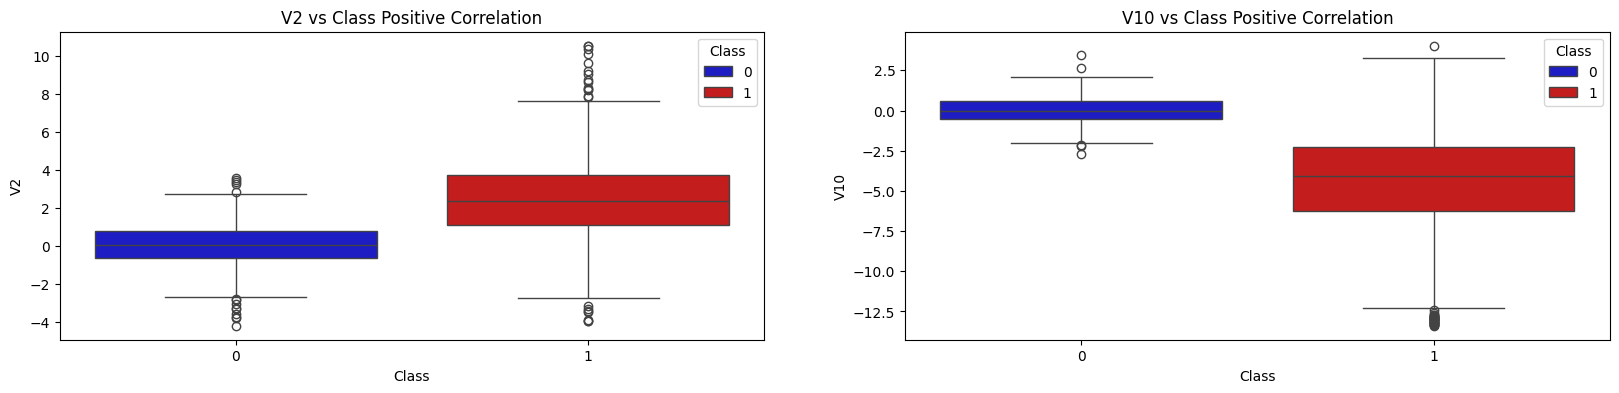

In [154]:
#Boxplot after removing IQR
f, axes = plt.subplots(ncols=2, figsize =(20,4))
sns.boxplot(x='Class', y="V2", data=new_df, ax=axes[0], palette=colors, hue="Class")
axes[0].set_title("V2 vs Class Positive Correlation")

sns.boxplot(x='Class', y="V10", data=new_df, ax=axes[1], palette=colors, hue="Class")
axes[1].set_title("V10 vs Class Positive Correlation")
plt.show()


In [ ]:
#Remaining rows
new_df.shape

(906, 31)

### Model Training

Continue using new_df as a main dataframe.

### Evaluation